# Single-cell ATAC-seq analysis through PEAKVI

This tutorial analyzes the public **10x Genomics 10k Human PBMCs, ATAC v2,
Chromium X** dataset. It starts with Cell Ranger ATAC outputs, performs
fragment-level and per-nucleus QC, creates a filtered peak-by-nucleus matrix,
trains PEAKVI, and audits the resulting latent space with UMAP, Leiden
clustering, technical covariates, and a cluster-marker accessibility example.

The workflow preserves raw peak counts, keeps QC and modeling separate, and
audits the learned representation for technical structure. This tutorial ends
after calling candidate cluster-associated accessible peaks with PEAKVI.

## Learning objectives

By the end, you should be able to:

- identify the 10x files needed for secondary scATAC analysis;
- interpret barcode rank, fragment periodicity, FRiP, TSS-associated fragments,
  nucleosome signal, duplicates, and mitochondrial reads;
- create transparent QC flags from the observed dataset;
- preserve raw peak counts in an AnnData layer;
- choose a peak feature set suitable for a teaching-scale PEAKVI run;
- train, save, and reload a PEAKVI model;
- construct a neighborhood graph, UMAP, and Leiden clusters from `X_peakvi`;
- check whether the learned representation still follows fragment depth or QC;
- call and interpret candidate accessible peaks for one robust cluster.

## Reproducibility and compute

Create the environment with `environment.yml`, then run
`scripts/download_data.sh` and `scripts/prepare_fragment_metrics.sh`.

The complete fragment file is about 2.3 GB. PEAKVI is much faster with a GPU.
The rendered example uses 50,000 accessible regions and a cached trained model
so that the notebook can be reviewed on a CPU. For a research analysis with a
GPU, increase the feature count only after checking memory and convergence.

In [1]:
import os
import sys
import logging
import warnings
from importlib.metadata import version
from pathlib import Path

os.environ.setdefault("XDG_CACHE_HOME", "/tmp/learn_gencore_scatac_xdg")
os.environ.setdefault("MPLCONFIGDIR", "/tmp/learn_gencore_scatac_mpl")
os.environ.setdefault("NUMBA_CACHE_DIR", "/tmp/learn_gencore_scatac_numba")
os.environ.setdefault("KMP_WARNINGS", "0")
warnings.filterwarnings("ignore", message="IProgress not found.*")

import matplotlib.pyplot as plt
import pandas as pd
import scanpy as sc
import scvi
from IPython.display import display

cwd = Path.cwd().resolve()
candidates = [
    cwd.parent if cwd.name == "notebooks" else cwd,
    cwd / "source" / "epigenomics" / "scatac_tutorial",
]
tutorial_dir = next(path for path in candidates if (path / "scripts").exists())
repo_root = tutorial_dir.parents[2]
raw_dir = tutorial_dir / "data" / "raw"
processed_dir = tutorial_dir / "data" / "processed"
results_dir = tutorial_dir / "results"
figure_dir = repo_root / "source" / "img" / "epigenomics" / "scatac"
sys.path.insert(0, str(tutorial_dir / "scripts"))

from peakvi_workflow import (
    add_qc_flags,
    build_peakvi_graph,
    choose_qc_thresholds,
    filter_for_peakvi,
    latent_qc_correlations,
    load_atac_dataset,
    plot_barcode_rank,
    plot_cluster_qc,
    plot_differential_accessibility,
    plot_fragment_length,
    plot_latent_qc_correlations,
    plot_peakvi_umap,
    plot_qc_distributions,
    plot_qc_relationships,
    plot_training_history,
    qc_summary,
    run_peakvi_differential_accessibility,
    save_figure,
    set_plot_style,
    train_peakvi,
    training_history_frame,
    validate_cache_manifest,
    write_cache_manifest,
    write_results,
)

set_plot_style()
scvi.settings.verbosity = logging.WARNING
print("scanpy:", version("scanpy"))
print("scvi-tools:", version("scvi-tools"))

scanpy: 1.11.5
scvi-tools: 1.4.2


## 1. Check the public inputs

The peak matrix contains called nuclei only. `singlecell.csv` also contains
background barcodes and Cell Ranger fragment counts, which lets us reconstruct
the barcode-rank and several QC plots. The fragment file is needed for fragment
periodicity and nucleosome signal.

The dataset page is:
https://www.10xgenomics.com/datasets/10k-human-pbmcs-atac-v2-chromium-x-2-standard

In [2]:
required_inputs = [
    (raw_dir, "filtered_peak_bc_matrix.h5", "raw"),
    (raw_dir, "singlecell.csv", "raw"),
    (raw_dir, "peak_annotation.tsv", "raw"),
    (raw_dir, "fragments.tsv.gz", "raw"),
    (raw_dir, "fragments.tsv.gz.tbi", "raw"),
    (processed_dir, "fragment_metrics.tsv", "processed"),
    (processed_dir, "fragment_length_histogram.tsv", "processed"),
]
input_status = pd.DataFrame(
    {
        "location": [location for _, _, location in required_inputs],
        "file": [name for _, name, _ in required_inputs],
        "present": [(directory / name).exists() for directory, name, _ in required_inputs],
        "size_GB": [
            round((directory / name).stat().st_size / 1e9, 3)
            if (directory / name).exists()
            else None
            for directory, name, _ in required_inputs
        ],
    }
)
display(input_status)
assert input_status["present"].all(), (
    "Run scripts/download_data.sh and scripts/prepare_fragment_metrics.sh "
    "before continuing."
)

,location,file,present,size_GB
0,raw,filtered_peak_bc_matrix.h5,True,0.157
1,raw,singlecell.csv,True,0.031
2,raw,peak_annotation.tsv,True,0.009
3,raw,fragments.tsv.gz,True,2.336
4,raw,fragments.tsv.gz.tbi,True,0.001
5,processed,fragment_metrics.tsv,True,0.000
6,processed,fragment_length_histogram.tsv,True,0.000


## 2. Load the peak matrix and attach QC metadata

Raw peak counts are preserved in `adata.layers["counts"]`. The matrix has
nuclei as rows and genomic regions as columns. The peak annotation file may
contain more than one candidate gene for a region, so the loader retains the
closest entry only for descriptive metadata.

In [3]:
adata, singlecell_all = load_atac_dataset(raw_dir, processed_dir)
print(adata)
print(f"Called nuclei: {adata.n_obs:,}")
print(f"Called peaks: {adata.n_vars:,}")

AnnData object with n_obs × n_vars = 10273 × 164487
    obs: 'total', 'duplicate', 'chimeric', 'unmapped', 'lowmapq', 'mitochondrial', 'nonprimary', 'passed_filters', 'is__cell_barcode', 'excluded_reason', 'TSS_fragments', 'DNase_sensitive_region_fragments', 'enhancer_region_fragments', 'promoter_region_fragments', 'on_target_fragments', 'blacklist_region_fragments', 'peak_region_fragments', 'peak_region_cutsites', 'n_fragments', 'nucleosome_free_fragments', 'mononucleosomal_fragments', 'nucleosome_signal', 'frip', 'tss_fraction', 'duplicate_fraction', 'mitochondrial_fraction', 'log10_fragments', 'n_genes_by_counts', 'total_counts'
    var: 'gene_ids', 'feature_types', 'derivation', 'genome', 'chrom', 'start', 'end', 'gene', 'distance', 'peak_type', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    layers: 'counts'
Called nuclei: 10,273
Called peaks: 164,487


## 3. Inspect cell calling and fragment periodicity

The barcode-rank curve separates called nuclei from background barcodes. The
fragment-length curve should show a strong nucleosome-free component and
periodic mono- and di-nucleosomal structure. These are sample-level checks and
should be reviewed before choosing cell-level thresholds.

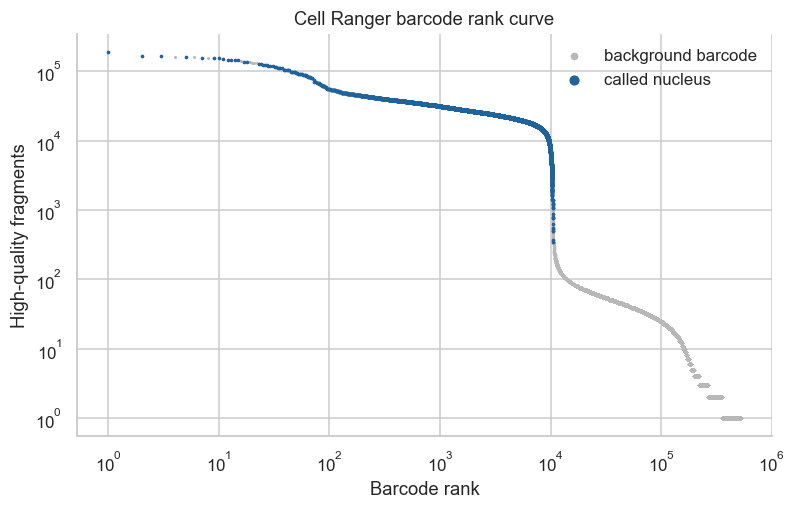

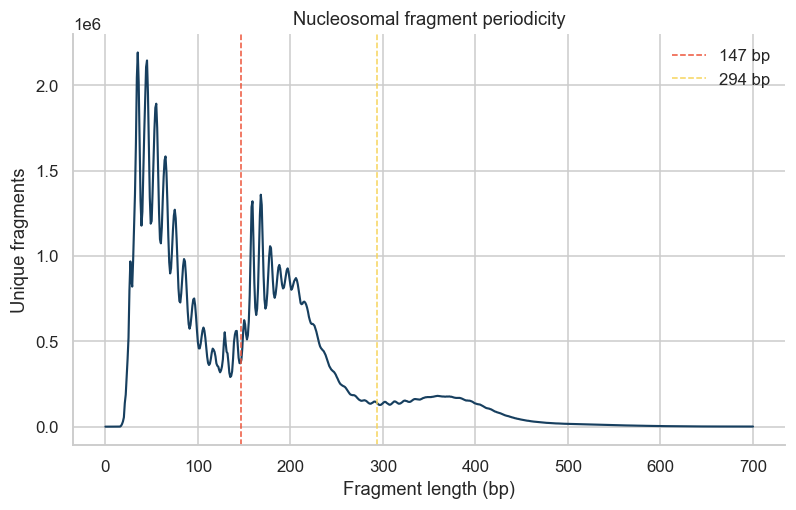

In [4]:
fig = plot_barcode_rank(singlecell_all)
save_figure(fig, figure_dir / "01_barcode_rank.png")
plt.show()

fig = plot_fragment_length(processed_dir)
save_figure(fig, figure_dir / "02_fragment_length.png")
plt.show()

## 4. Define transparent QC flags

This example uses the observed lower 1% tails for fragment count, FRiP, and
TSS-associated fragment fraction, the upper 0.5% tail for fragment count, and
the upper 1% tail for nucleosome signal. These are review thresholds for this
dataset, not universal scATAC cutoffs.

`tss_fraction` is the fraction of Cell Ranger high-quality fragments assigned
near annotated TSS regions. It should not be confused with the aggregate TSS
enrichment score calculated from a TSS-centered insertion profile.

,threshold
min_fragments,3000.00
max_fragments,82700.00
min_frip,0.23
min_tss_fraction,0.16
max_nucleosome_signal,6.60


,measure,value
0,called nuclei,10273.000000
1,nuclei passing tutorial QC,9995.000000
2,nuclei flagged,278.000000
3,median high-quality fragments,20046.000000
4,median FRiP,0.686442
5,median TSS fraction,0.491179


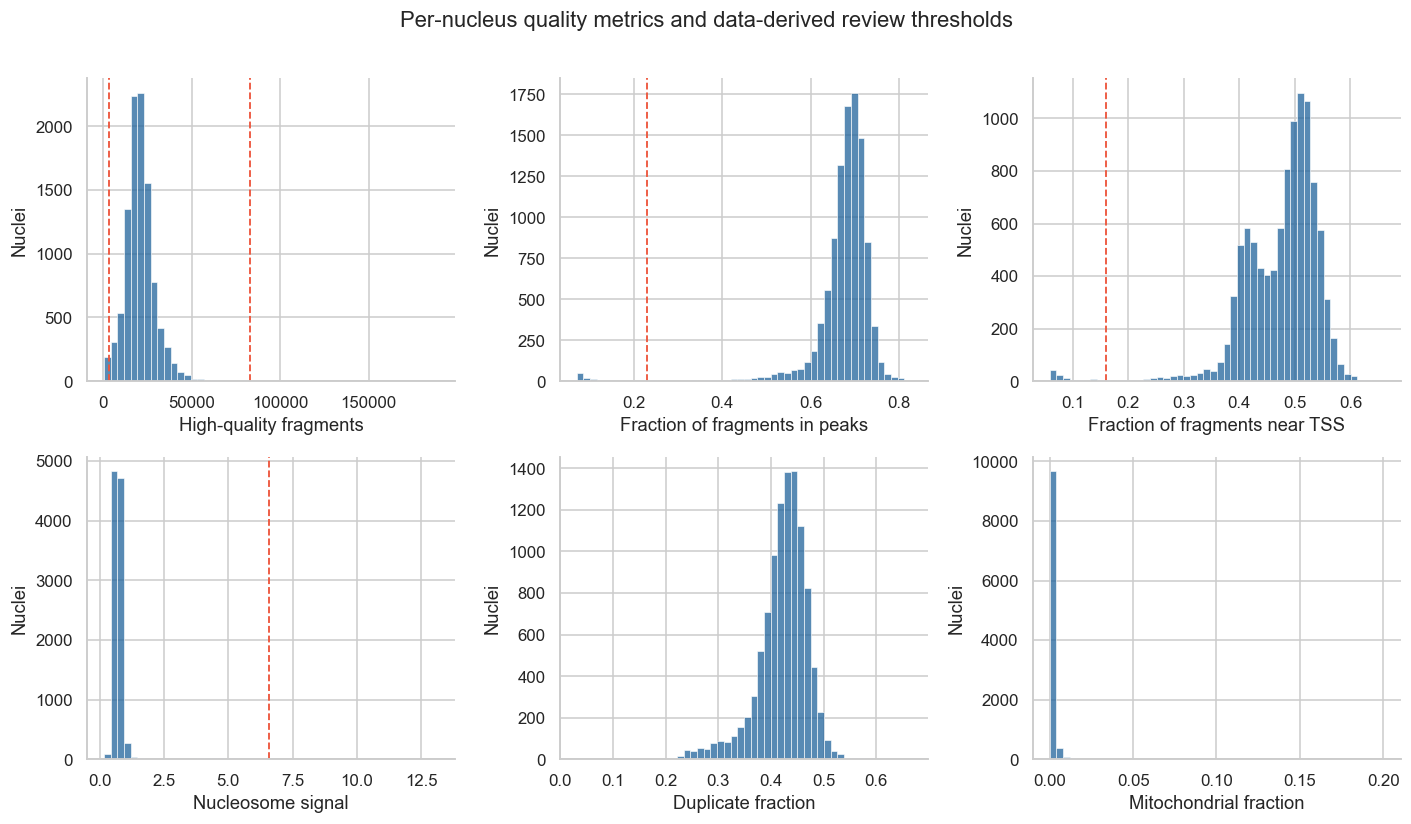

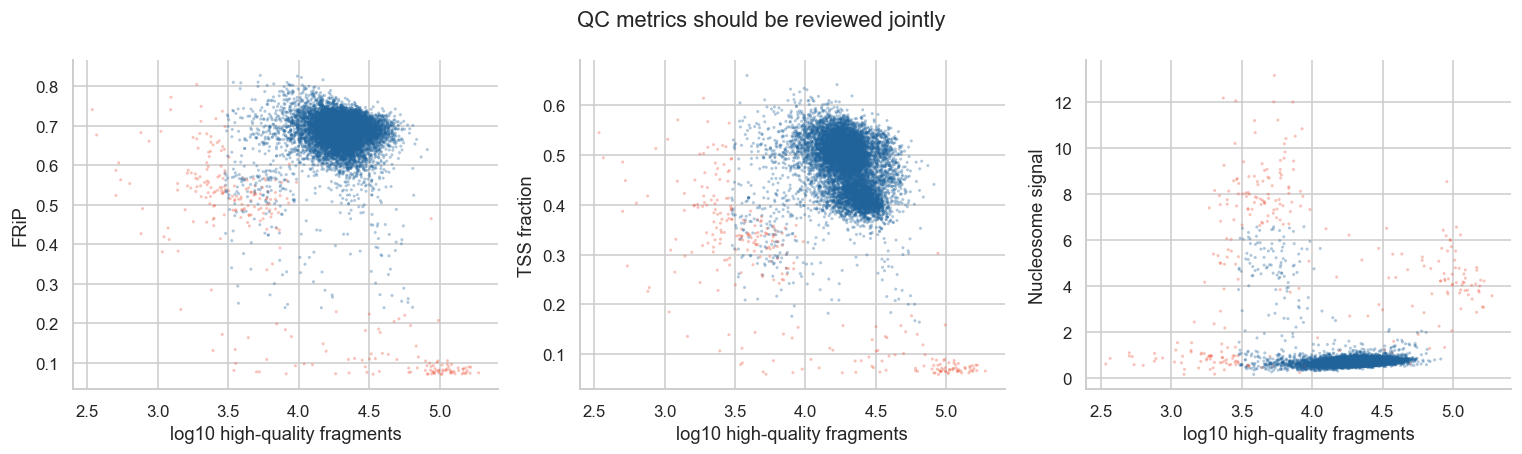

In [5]:
thresholds = choose_qc_thresholds(adata)
add_qc_flags(adata, thresholds)

display(pd.Series(thresholds, name="threshold").to_frame())
display(qc_summary(adata))

fig = plot_qc_distributions(adata, thresholds)
save_figure(fig, figure_dir / "03_qc_distributions.png")
plt.show()

fig = plot_qc_relationships(adata)
save_figure(fig, figure_dir / "04_qc_relationships.png")
plt.show()

## 5. Prepare the matrix for PEAKVI

We retain nuclei that pass all tutorial QC flags and peaks detected in at least
20 retained nuclei. The CPU-rendered notebook then keeps the 50,000 peaks with
the largest binary accessibility variance. This is a compute-aware teaching
choice. It must be reported because feature selection changes the model input.

PEAKVI models whether each region is accessible, while accounting for cell and
region detection effects. It accepts binary or count matrices. Here the
unmodified Cell Ranger counts remain in the `counts` layer.

In [6]:
peakvi_adata = filter_for_peakvi(
    adata,
    min_cells_per_peak=20,
    max_peaks=50_000,
)
print(peakvi_adata)
print(f"Retained nuclei: {peakvi_adata.n_obs:,}")
print(f"Retained peaks: {peakvi_adata.n_vars:,}")

AnnData object with n_obs × n_vars = 9995 × 50000
    obs: 'total', 'duplicate', 'chimeric', 'unmapped', 'lowmapq', 'mitochondrial', 'nonprimary', 'passed_filters', 'is__cell_barcode', 'excluded_reason', 'TSS_fragments', 'DNase_sensitive_region_fragments', 'enhancer_region_fragments', 'promoter_region_fragments', 'on_target_fragments', 'blacklist_region_fragments', 'peak_region_fragments', 'peak_region_cutsites', 'n_fragments', 'nucleosome_free_fragments', 'mononucleosomal_fragments', 'nucleosome_signal', 'frip', 'tss_fraction', 'duplicate_fraction', 'mitochondrial_fraction', 'log10_fragments', 'n_genes_by_counts', 'total_counts', 'qc_low_fragments', 'qc_high_fragments', 'qc_low_frip', 'qc_low_tss', 'qc_high_nucleosome', 'qc_pass', 'qc_reason'
    var: 'gene_ids', 'feature_types', 'derivation', 'genome', 'chrom', 'start', 'end', 'gene', 'distance', 'peak_type', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'detection_rate'
    layers: 'counts'


## 6. Train or reload PEAKVI

Set `RUN_TRAINING = True` to fit the model in this notebook. The rendered copy
reloads the model generated by `scripts/run_peakvi.py`. Saving the model avoids
repeating a several-minute CPU training run and makes the result auditable.

For a multi-library dataset, pass a real library or batch column as
`batch_key` during `PEAKVI.setup_anndata`. This public example has one sample,
so there is no estimable biological batch effect.

,value
max_epochs,100.0
max_peaks,50000.0
min_cells_per_peak,20.0
resolution,0.6
n_latent,15.0
seed,17.0


,kl_weight,validation_loss,elbo_validation,reconstruction_loss_validation,kl_local_validation,kl_global_validation,train_loss,elbo_train,reconstruction_loss_train,kl_local_train,kl_global_train
95,1.0,278368608.0,17710.621094,17634.941406,75.678741,0.0,281846496.0,17335.134766,17262.056641,73.078598,0.0
96,1.0,278415968.0,17713.787109,17637.513672,76.273071,0.0,281733632.0,17332.546875,17259.341797,73.205391,0.0
97,1.0,278339200.0,17708.722656,17632.945312,75.776573,0.0,281652896.0,17329.884766,17256.673828,73.211327,0.0
98,1.0,278547712.0,17721.500000,17646.058594,75.441513,0.0,281644608.0,17327.279297,17254.125000,73.154907,0.0
99,1.0,278359104.0,17710.414062,17634.390625,76.023224,0.0,281620288.0,17324.330078,17251.119141,73.210793,0.0


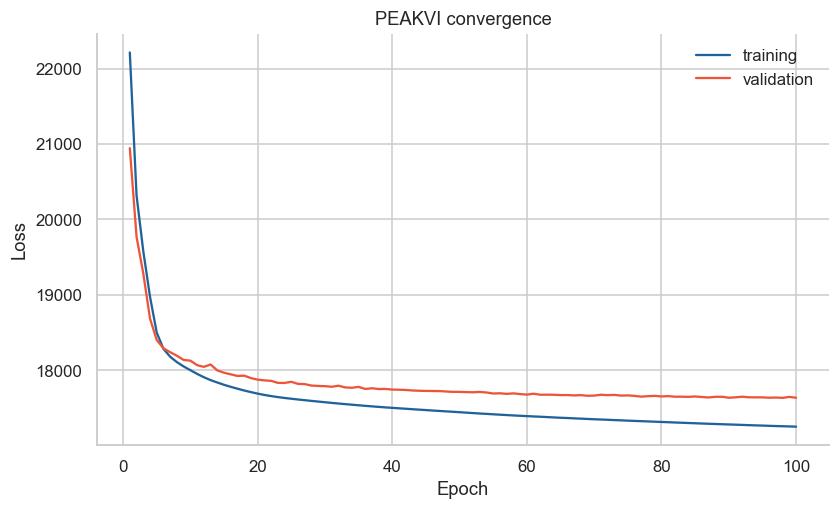

In [7]:
RUN_TRAINING = False
model_dir = results_dir / "models" / "peakvi_pbmc"
manifest_path = results_dir / "peakvi_cache_manifest.json"
history_path = results_dir / "peakvi_training_history.tsv"

if RUN_TRAINING:
    model = train_peakvi(
        peakvi_adata,
        model_dir=model_dir,
        max_epochs=100,
        n_latent=15,
        seed=17,
    )
    history = training_history_frame(model)
    history.to_csv(history_path, sep="	", index=False)
    manifest = write_cache_manifest(
        peakvi_adata,
        manifest_path,
        parameters={
            "max_epochs": 100,
            "max_peaks": 50_000,
            "min_cells_per_peak": 20,
            "resolution": 0.6,
            "n_latent": 15,
            "seed": 17,
        },
    )
else:
    required_cache = [model_dir / "model.pt", history_path, manifest_path]
    missing_cache = [str(path) for path in required_cache if not path.exists()]
    if missing_cache:
        raise FileNotFoundError(
            "Cached PEAKVI outputs are missing. Run `python scripts/run_peakvi.py` "
            "from the tutorial directory, or set RUN_TRAINING = True. Missing: "
            + ", ".join(missing_cache)
        )
    manifest = validate_cache_manifest(peakvi_adata, manifest_path)
    scvi.model.PEAKVI.setup_anndata(peakvi_adata, layer="counts")
    model = scvi.model.PEAKVI.load(
        model_dir,
        adata=peakvi_adata,
        accelerator="cpu",
        device="auto",
    )
    peakvi_adata.obsm["X_peakvi"] = model.get_latent_representation()
    history = pd.read_csv(history_path, sep="	")

display(pd.Series(manifest["parameters"], name="value").to_frame())
display(history.tail())
fig = plot_training_history(history)
save_figure(fig, figure_dir / "05_peakvi_training.png")
plt.show()

## 7. Audit the PEAKVI latent representation

A model can converge while retaining unwanted technical structure. We inspect
the correlation of every latent dimension with fragment depth, FRiP,
TSS-associated fragment fraction, and nucleosome signal before interpreting
the embedding.

,component,metric,correlation
14,4,tss_fraction,0.733987
18,5,tss_fraction,0.675713
56,15,log10_fragments,-0.638188
54,14,tss_fraction,0.629305
34,9,tss_fraction,0.542925
6,2,tss_fraction,-0.530982
42,11,tss_fraction,0.513392
50,13,tss_fraction,-0.508876
10,3,tss_fraction,-0.478217
58,15,tss_fraction,0.469915


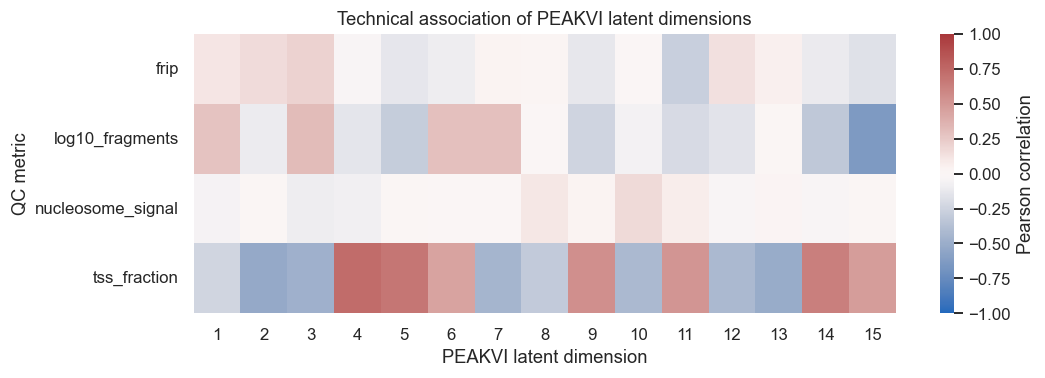

In [8]:
correlations = latent_qc_correlations(peakvi_adata)
display(correlations.reindex(correlations["correlation"].abs().sort_values(ascending=False).index).head(12))

fig = plot_latent_qc_correlations(correlations)
save_figure(fig, figure_dir / "06_peakvi_latent_qc.png")
plt.show()

## 8. Build the neighborhood graph, UMAP, and Leiden clusters

The graph and UMAP are computed from `X_peakvi`, not directly from the sparse
peak matrix. Coloring the same embedding by QC variables makes depth-driven or
low-quality islands visible. The cluster-level boxplots provide a second check
that a cluster is not simply a technical tail.

leiden_peakvi
0     1540
1     1285
2     1258
3     1201
4      925
5      634
6      595
7      583
8      499
9      308
10     267
11     259
12     192
13     190
14     186
15      48
16      25
Name: count, dtype: int64


,n_nuclei,median_fragments,median_frip,median_tss_fraction,median_nucleosome_signal
leiden_peakvi,,,,,
0,1540,25597.0,0.706542,0.415922,0.669771
1,1285,19656.0,0.678217,0.502312,0.712008
2,1258,18651.5,0.669271,0.506272,0.744246
3,1201,19781.0,0.685303,0.517360,0.669811
4,925,16165.0,0.684404,0.514121,0.675436
5,634,17434.0,0.684101,0.517072,0.676294
6,595,16172.0,0.711998,0.418844,0.645149
7,583,19199.0,0.677462,0.505946,0.672350
8,499,19855.0,0.692872,0.488825,0.643311


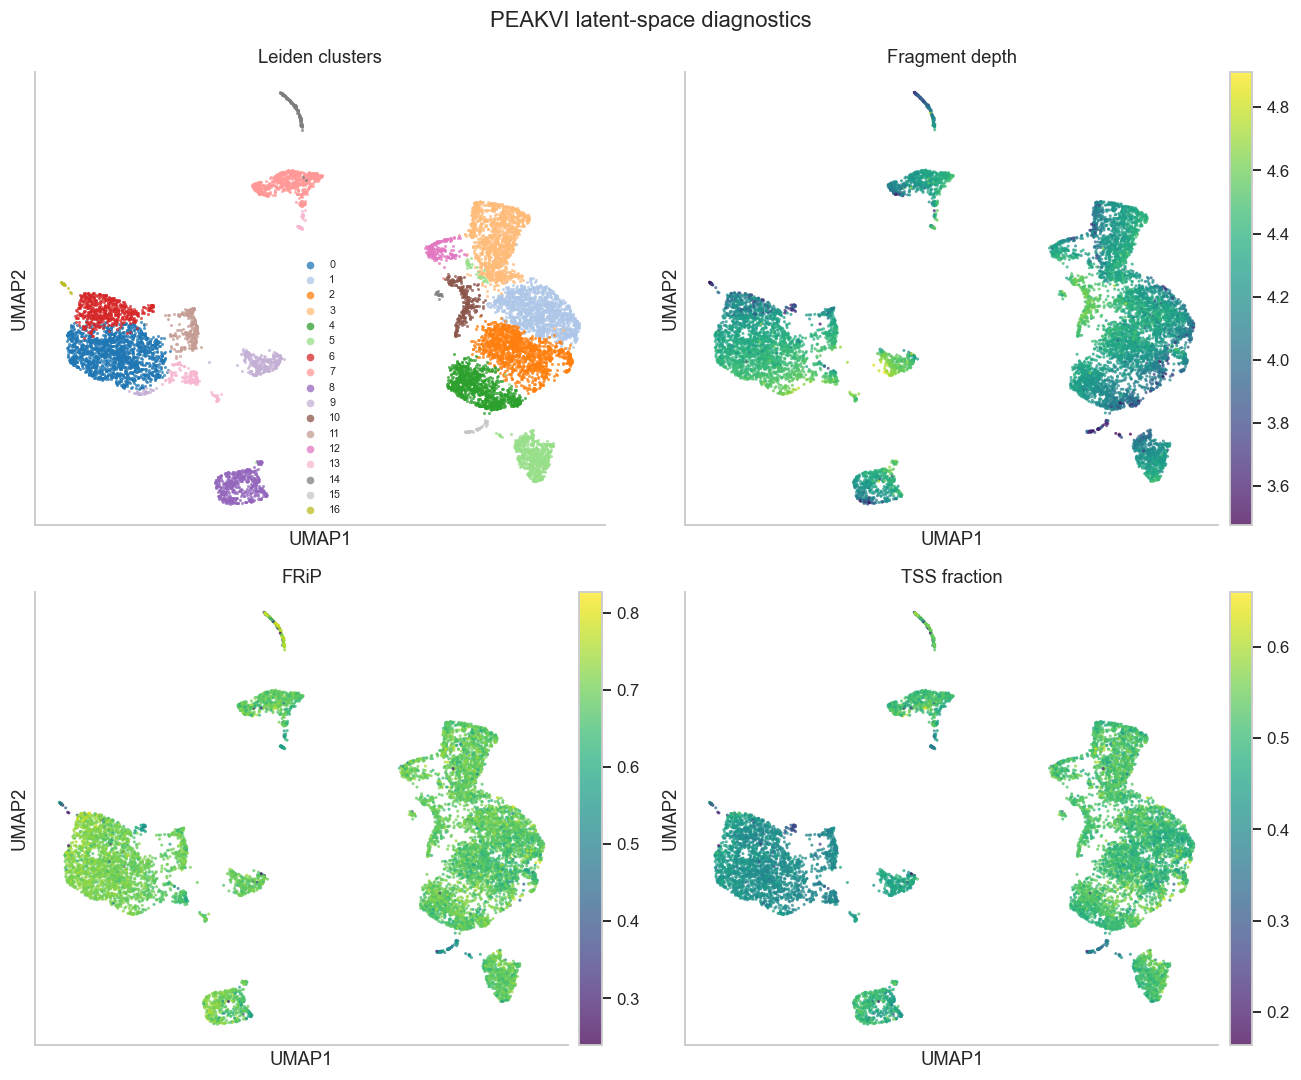

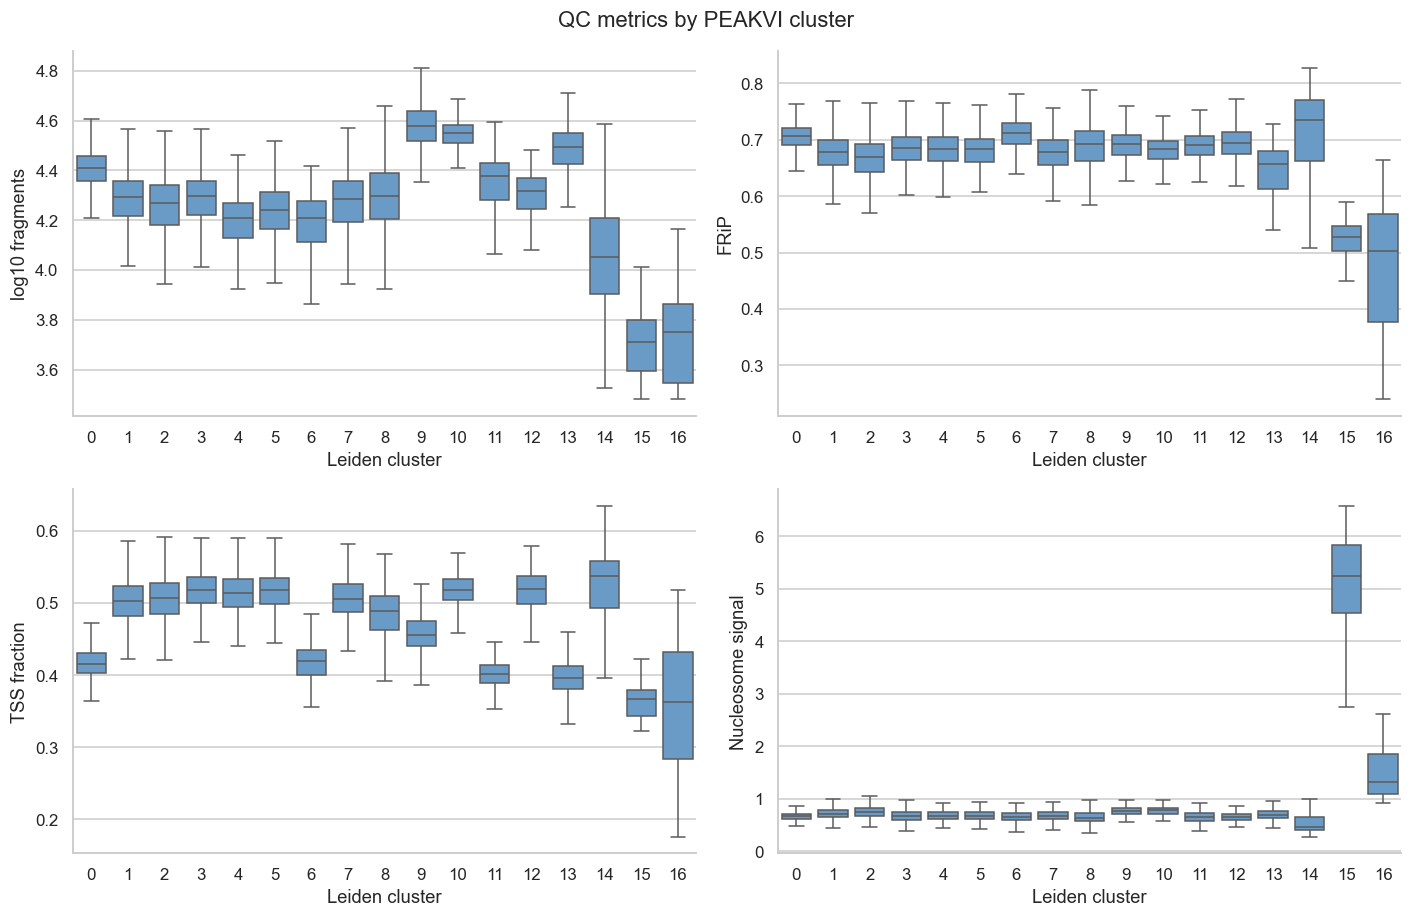

In [9]:
build_peakvi_graph(peakvi_adata, resolution=0.6, seed=17)
print(peakvi_adata.obs["leiden_peakvi"].value_counts().sort_index())

cluster_qc = peakvi_adata.obs.groupby("leiden_peakvi", observed=True).agg(
    n_nuclei=("leiden_peakvi", "size"),
    median_fragments=("passed_filters", "median"),
    median_frip=("frip", "median"),
    median_tss_fraction=("tss_fraction", "median"),
    median_nucleosome_signal=("nucleosome_signal", "median"),
)
display(cluster_qc)

fig = plot_peakvi_umap(peakvi_adata)
save_figure(fig, figure_dir / "07_peakvi_umap.png")
plt.show()

fig = plot_cluster_qc(peakvi_adata)
save_figure(fig, figure_dir / "08_peakvi_cluster_qc.png")
plt.show()

## 9. Call candidate cluster-associated accessible peaks

PEAKVI can compare accessibility between cell groups at individual regions.
Here cluster 0, the largest cluster after per-nucleus QC and review of the
diagnostics above, is compared with all other retained nuclei. This reference
group is a heterogeneous mixture and includes clusters 15 and 16, whose QC
profiles warrant sensitivity analysis before biological interpretation.

The model uses its default posterior change threshold (`delta=0.05`) and a
posterior expected FDR target of 0.05. In the scvi-tools implementation used
here, `delta` applies to a posterior log2 accessibility change calculated with
an estimated pseudocount. It is not an absolute five-percentage-point cutoff.

For a compact teaching table, we additionally require an estimated effect of
at least 0.10 toward the target cluster, an empirical effect of at least 0.05,
and empirical detection in at least 5% of target nuclei. These extra filters
are reporting choices, not part of PEAKVI's expected-FDR calculation.

The returned `effect_size` is a separate absolute probability difference:
`comparison - target`. A negative value therefore means greater accessibility
in the target cluster. The tested universe is the 50,000 peaks supplied to
this CPU teaching model. The rendered analysis uses 5,000 posterior samples,
which can require several gigabytes of memory at this feature count. A smaller
value such as 500 is useful for a quick preview, but thresholded calls can
change and final results should use the documented full setting.

Seed set to 17


,measure,value
0,target cluster,0
1,target nuclei,1540
2,comparison nuclei,8455
3,tested peaks,50000
4,PEAKVI posterior FDR calls,13222
5,candidate target-cluster markers after reporti...,11640


,peak,gene,distance,effect_size,emp_effect,prob_da,est_prob1,est_prob2,emp_prob1,emp_prob2
peak,,,,,,,,,,
chr7:36118963-36119864,chr7:36118963-36119864,AC083864.3,23650.0,-0.828657,-0.540947,0.9360,0.978839,0.150182,0.619481,0.078533
chr20:40339770-40340654,chr20:40339770-40340654,NaN,NaN,-0.828577,-0.507603,0.9386,0.970615,0.142038,0.581169,0.073566
chr1:212485671-212486568,chr1:212485671-212486568,LINC02771,-12767.0,-0.828333,-0.517703,0.9582,0.965682,0.137349,0.588312,0.070609
chr20:40506304-40507221,chr20:40506304-40507221,MAFB,182015.0,-0.827269,-0.534400,0.9444,0.969567,0.142299,0.609740,0.075340
chr8:133150078-133151002,chr8:133150078-133151002,CCN4,-40037.0,-0.825063,-0.562721,0.9276,0.982445,0.157382,0.646104,0.083383
chr11:130123839-130124747,chr11:130123839-130124747,APLP2,0.0,-0.824181,-0.505648,0.9458,0.976283,0.152102,0.583117,0.077469
chr5:140321539-140322442,chr5:140321539-140322442,PFDN1,-18427.0,-0.824031,-0.493310,0.9400,0.976671,0.152640,0.570779,0.077469
chr13:48782986-48783899,chr13:48782986-48783899,CYSLTR2,76432.0,-0.823807,-0.537462,0.9502,0.974558,0.150751,0.617532,0.080071
chr7:112080367-112081390,chr7:112080367-112081390,DOCK4,-76236.0,-0.822740,-0.563614,0.9590,0.975570,0.152829,0.642857,0.079243


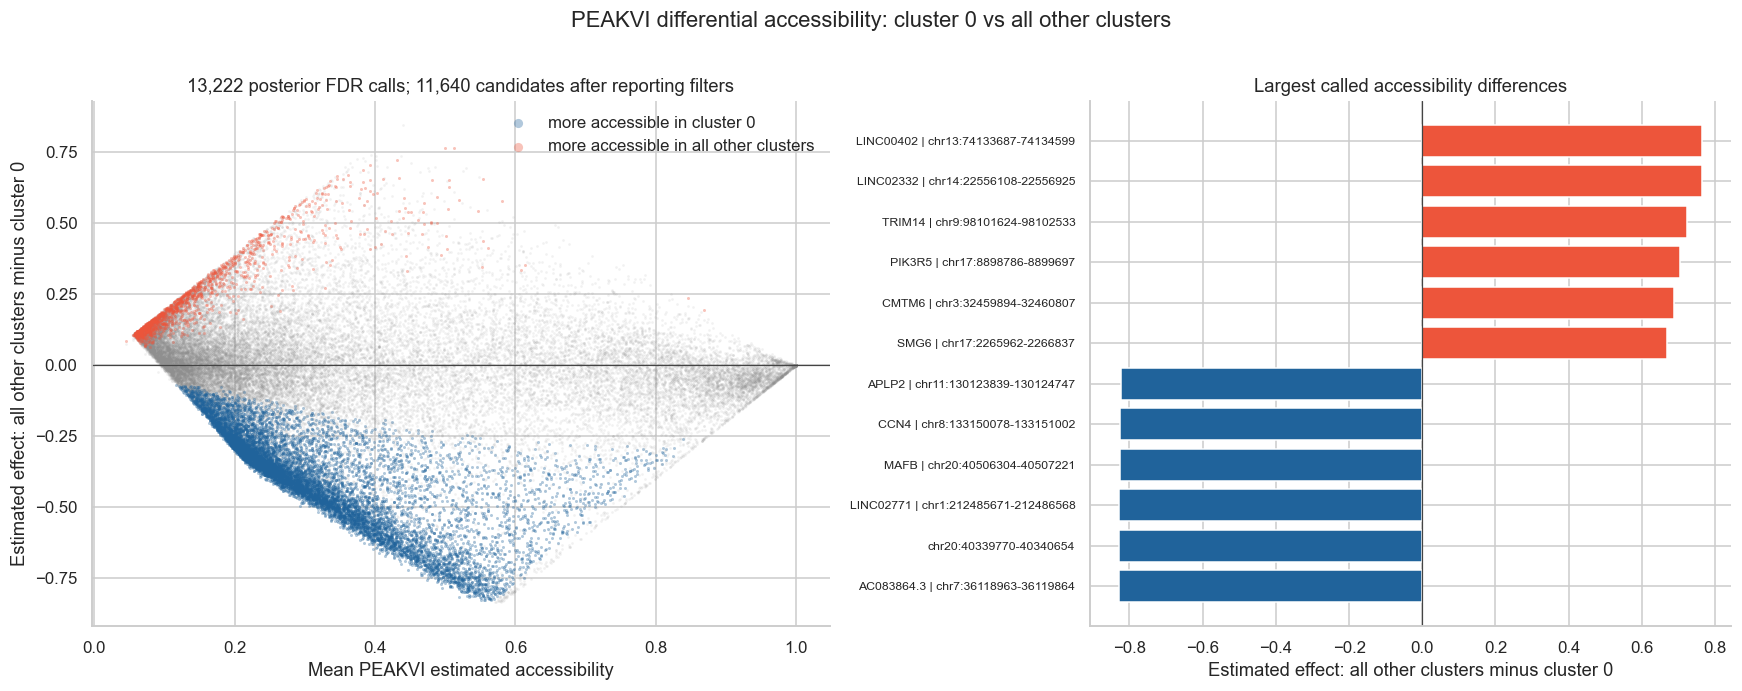

In [10]:
group1 = "0"
group2 = None
da_results = run_peakvi_differential_accessibility(
    model,
    peakvi_adata,
    group1=group1,
    group2=group2,
    delta=0.05,
    fdr_target=0.05,
    n_samples_overall=5_000,
    seed=17,
)

da_summary = pd.DataFrame(
    {
        "measure": [
            "target cluster",
            "target nuclei",
            "comparison nuclei",
            "tested peaks",
            "PEAKVI posterior FDR calls",
            "candidate target-cluster markers after reporting filters",
        ],
        "value": [
            group1,
            int(peakvi_adata.obs["leiden_peakvi"].astype(str).eq(group1).sum()),
            int(peakvi_adata.obs["leiden_peakvi"].astype(str).ne(group1).sum()),
            len(da_results),
            int(da_results["is_da_fdr"].sum()),
            int(da_results["tutorial_marker"].sum()),
        ],
    }
)
display(da_summary)

marker_columns = [
    "peak",
    "gene",
    "distance",
    "effect_size",
    "emp_effect",
    "prob_da",
    "est_prob1",
    "est_prob2",
    "emp_prob1",
    "emp_prob2",
]
display(da_results.loc[da_results["tutorial_marker"], marker_columns].head(20))

fig = plot_differential_accessibility(da_results, group1=group1, group2=group2)
save_figure(fig, figure_dir / "09_peakvi_differential_accessibility.png")
plt.show()

## 10. Save compact, reusable results

The trained model is stored separately from the public input data. The compact
results contain UMAP coordinates, clusters, QC metrics, latent-to-QC
correlations, and the complete peak-level comparison.

In [11]:
write_results(peakvi_adata, thresholds, correlations, results_dir)
da_results.to_csv(
    results_dir / f"peakvi_da_cluster_{group1}_vs_rest.tsv.gz",
    sep="	",
    index=False,
    compression="gzip",
)
print("Results written to", results_dir.relative_to(repo_root))

Results written to source/epigenomics/scatac_tutorial/results


## Interpretation and stopping point

At this point we have a QC-audited PEAKVI representation, unsupervised
clusters, and candidate cluster-associated accessible peaks. Cluster numbers
are not cell types, and the nearest gene is a positional annotation rather
than a demonstrated regulatory target.

In this rendered run, the two smallest clusters have lower fragment depth,
FRiP, and TSS fraction than the main groups, and one also has unusually high
nucleosome signal. They remain visible here because this is exactly the kind of
post-model QC finding that should trigger a documented sensitivity analysis
before cell-type annotation. A converged model does not make those nuclei
biological populations.

This single public donor supports a methods demonstration, descriptive
clustering, and marker accessibility within this sample. It does not support
donor-level or condition-level differential accessibility, batch-effect
estimation, or population claims. Those analyses require independent
biological replicates and a sample-aware design.

Common pitfalls at this stage include filtering with copied thresholds,
discarding rare nuclei because their QC distributions differ, treating UMAP
distance as a quantitative effect size, calling clusters cell types without
orthogonal evidence, and assuming model convergence removes all technical
structure. Cluster marker discovery is also partly circular because clustering
and peak testing use the same selected accessibility matrix.